# Seurat Label Transfer
**Pinned Environment:** [`envs/R_integration.yaml`](../.../envs/R_integration.yaml)

Reference mapping guide: https://www.10xgenomics.com/analysis-guides/xenium-cell-type-annotation

in environment in terminal:
- remotes::install_github("bnprks/BPCells/r")

In [1]:
packageVersion("Seurat")

[1] ‘5.3.0’

In [2]:
library(Seurat)
library(BPCells)
library(SeuratObject)
# library(SeuratDisk)
library(tidyverse)
library(jsonlite)
options(future.globals.maxSize = 1e9)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    intersect, t


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.2
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘jsonlite’


The following object is masked from ‘package:purrr’:

    flatten




In [3]:
library(ggplot2)
library(ggpmisc)
library(scales)
library(cowplot)
library(gridExtra)
library(viridis)
library(hrbrthemes)

Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘scales’


The following object is masked from ‘package:purrr’:

    discard


The following object is masked from ‘package:readr’:

    col_factor



Attaching package: ‘cowplot’


The following object is masked from ‘package:lubridate’:

    stamp



Attaching package: ‘gridExtra’


The following object is masked from ‘package:dplyr’:

    combine


Loading required package: viridisLite


Attaching package: ‘viridis’


The following object is masked from ‘package:scales’:

    viridis_pal




## File info

In [4]:
repo_root <- normalizePath(file.path(getwd(), ".."))

cmd <- paste0(
  "PYTHONPATH=", repo_root,
  " python3 -c 'import sys; from pathlib import Path; sys.path.append(str(Path.cwd().resolve().parents[1])); ",
  "from config.paths import BASE_DIR; print(BASE_DIR)'"
)

base_dir <- file.path(system(cmd, intern = TRUE), "data", "rds")

In [5]:
repo_root

[1] "/home/workspace/DRG/spatial_mouse_drg_innervation/yano/notebooks_KA_reprocess"

In [6]:
# Folder where the .rds files were saved
# input_dir <- file.path(base_dir, "seurat")
input_dir <- file.path(base_dir, "data", "rds", "seurat")

# Full paths to the Xenium and reference RDS files
xenium_rds_file  <- file.path(input_dir, "adata-xenium.rds")
refdata_rds_file <- file.path(input_dir, "refdata-seq.rds")

# Output folder for downstream label transfer or plots
output_dir <- file.path(base_dir, "seurat")
dir.create(output_dir, recursive = TRUE, showWarnings = FALSE)

In [7]:
print(input_dir)
print(xenium_rds_file)
print(refdata_rds_file)
print(output_dir)

[1] "/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/data/rds/seurat"
[1] "/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/data/rds/seurat/adata-xenium.rds"
[1] "/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/data/rds/seurat/refdata-seq.rds"
[1] "/home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/seurat"


## Load reference reference


In [8]:
ref <- readRDS(refdata_rds_file)

In [9]:
ref

An object of class Seurat 
28737 features across 36241 samples within 1 assay 
Active assay: RNA (28737 features, 0 variable features)
 1 layer present: counts
 2 dimensional reductions calculated: latent, umap

In [10]:
group_counts_df <- as.data.frame(table(ref$cell_label))
colnames(group_counts_df) <- c("group", "count")

print("Annotation counts:")
print(group_counts_df)

[1] "Annotation counts:"
                        group count
1                 Abeta-Field   245
2               Abeta-RA-LTMR   265
3                 Adelta-LTMR   153
4               Angiogenic EC   182
5                      C-LTMR  1415
6                  CGRP-Alpha  1440
7                   CGRP-Beta   134
8               CGRP-Epsilion   848
9                    CGRP-Eta   257
10                 CGRP-Gamma   696
11                 CGRP-Theta   735
12                  CGRP-Zeta   321
13                Cycling SGC   340
14               Fibroblast_1   282
15               Fibroblast_2   207
16               Macrophage_1   405
17               Macrophage_2   146
18 Nonpeptidergic nociceptors  2669
19                   Pericyte   605
20             Proprioceptors   228
21                        SGC 15210
22               Schwann_cell  2699
23                        Sst   757
24                      TrpM8   485
25                    Unknown    81
26     Vascular_endothelial_1  5007
27 

## Load Xenium 

In [11]:
xenium.obj <- readRDS(xenium_rds_file)
DefaultAssay(xenium.obj) <- "Xenium"

In [12]:
xenium.obj

An object of class Seurat 
475 features across 72778 samples within 1 assay 
Active assay: Xenium (475 features, 0 variable features)
 1 layer present: counts
 1 dimensional reduction calculated: latent

## Process xenium

### BP cells

In [13]:
# Path to store on-disk BPCells matrix
counts_dir <- file.path(input_dir, "xenium_counts_bpcells")

if (dir.exists(counts_dir)) {
  unlink(counts_dir, recursive = TRUE)
}

# Write the counts matrix to disk (BPCells format)
write_matrix_dir(
  mat = xenium.obj[["Xenium"]]$counts,
  dir = counts_dir
)

# Reload matrix in on-disk format and assign back into Seurat object
counts.mat <- open_matrix_dir(dir = counts_dir)
xenium.obj[["Xenium"]]$counts <- counts.mat

rm(counts.mat)

• Consider calling convert_matrix_type if a compressed integer matrix is intended.
This message is displayed once every 8 hours.


475 x 72778 IterableMatrix object with class MatrixDir

Row names: 1500009L16Rik, 6330403K07Rik ... Zfp691
Col names: aaaacmnk-1-0, aaababeb-1-0 ... oiebbmcl-1-3

Data type: double
Storage order: column major

Queued Operations:
1. Load compressed matrix from directory /home/workspace/DRG/spatial_mouse_drg_outputs/yano/data/rds/data/rds/seurat/xenium_counts_bpcells

### Xenium QC

[1] 197
[1] 75


Warning message:
“Default search for "data" layer in "Xenium" assay yielded no results; utilizing "counts" layer instead.”
Warning message:
“The `slot` argument of `FetchData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Warning message:
“`PackageCheck()` was deprecated in SeuratObject 5.0.0.
ℹ Please use `rlang::check_installed()` instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”


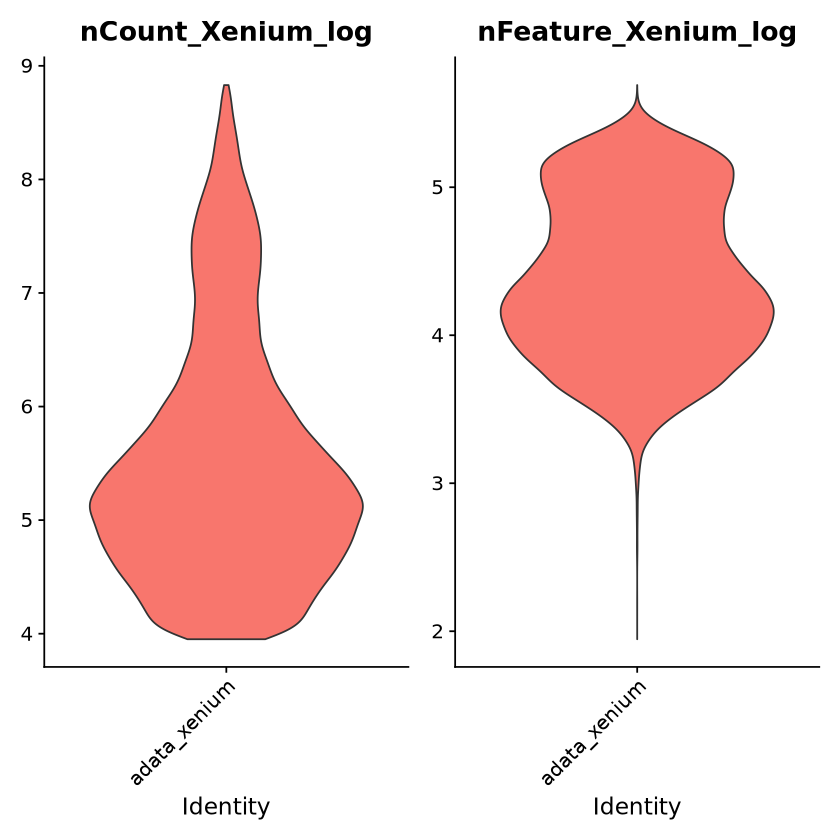

In [14]:
print(median(xenium.obj@meta.data$nCount_Xenium))
print(median(xenium.obj@meta.data$nFeature_Xenium))

# Add log1p_nCount_RNA, log1p_nFeatures
xenium.obj@meta.data$nCount_Xenium_log <- log1p(xenium.obj@meta.data$nCount_Xenium)
xenium.obj@meta.data$nFeature_Xenium_log <- log1p(xenium.obj@meta.data$nFeature_Xenium)

# remove cells with < 50 counts (aggressive filter)
xenium.obj <- subset(xenium.obj, subset = nCount_Xenium > 50)

# Violinplots of the transcript and feature counts per cell
VlnPlot(xenium.obj, features = c("nCount_Xenium_log", "nFeature_Xenium_log"), ncol = 2, pt.size = 0, group.by = "orig.ident")

In [15]:
# This function takes in the Xenium and single cell reference Seurat object and returns the per-gene expression means

get_gex_means <- function(xenium_obj, ref_obj){

    xen_means <- data.frame(
        mean_counts = rowMeans(xenium_obj[["Xenium"]]$counts),
        gene = rownames(xenium_obj[["Xenium"]]$counts)
    ) %>%
        arrange(desc(mean_counts)) %>%
        mutate(Rank = 1:n())

    ref_means <- data.frame(
        mean_counts = rowMeans(ref_obj[["RNA"]]$counts),
        gene = rownames(ref_obj[["RNA"]]$counts)
    ) %>%
        arrange(desc(mean_counts)) %>%
        mutate(Rank = 1:n())

    # Merge mean counts per cell,
    merged_means <- merge(xen_means, ref_means, by.x = "gene", by.y = "gene", all.x = TRUE)

    return(merged_means)
}


In [16]:
merged_means <- get_gex_means(xenium.obj, ref)

Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”
Warning message:
“Removed 6 rows containing non-finite outside the scale range
(`stat_poly_eq()`).”
Warning message:
“Removed 1 row containing missing values or values outside the scale range
(`geom_point()`).”


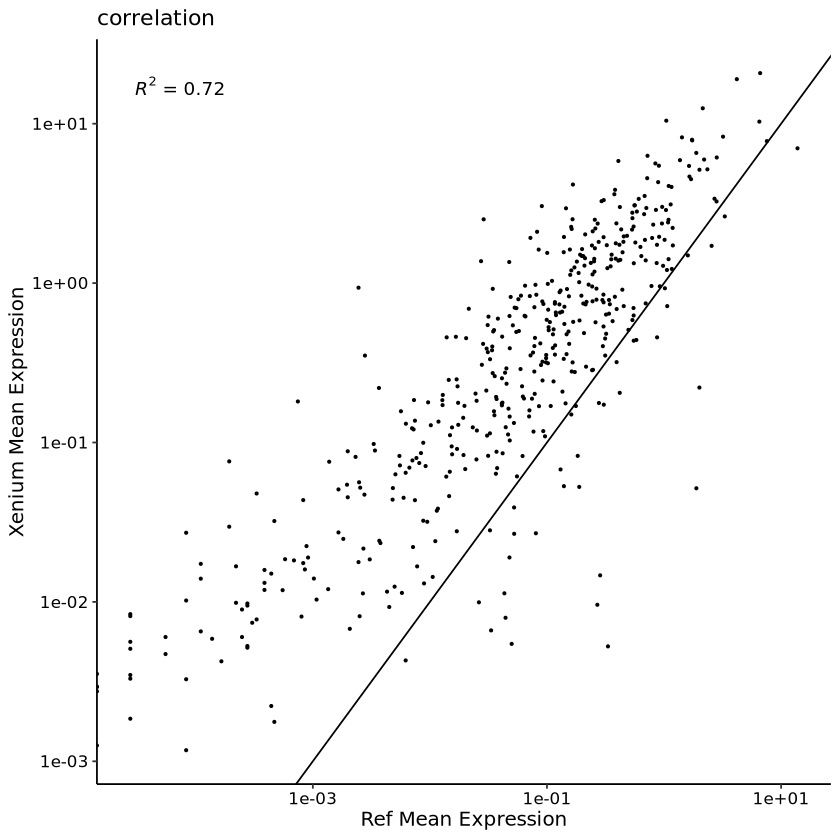

In [17]:
ggplot(merged_means, aes(x=mean_counts.y, y=mean_counts.x)) +
    geom_point(size=0.5) +
    scale_colour_manual(values=c("darkcyan", "coral")) +
    stat_poly_eq() +
    scale_x_log10() +
    scale_y_log10() +
    xlab("Ref Mean Expression") + ylab("Xenium Mean Expression") +
    ggtitle("correlation") +
    theme_classic() +
    theme(axis.text = element_text(color="black", size=10),
          axis.title = element_text(size=12)) +
    geom_abline(slope = 1, intercept = 0) 
    # tune::coord_obs_pred()

### Normalization, umap on reference

In [18]:
DefaultAssay(ref) <- "RNA"
ref <- NormalizeData(ref) %>%
                 FindVariableFeatures() %>%
                 ScaleData() %>%
                 RunPCA() %>%
                 RunUMAP(dims=1:15) %>%
                 FindNeighbors(dims=1:15) %>%
                 FindClusters(resolution=0.5)

Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

PC_ 1 
Positive:  Gm42418, Itih5, Ifitm3, Itm2a, Crip1, Ramp2, Col4a2, Txnip, Igfbp7, Tm4sf1 
	   Ly6c1, Cxcl12, Flt1, Klf2, Ly6a, Tcf4, Cdh5, Emcn, Id1, Ly6e 
	   Gsn, Mpz, Ctla2a, Cldn5, Esam, Srgn, Tjp1, Mfsd2a, Abcg2, Adgrl4 
Negative:  15-Sep, Serp2, Pcsk1n, AI413582, Phf24, Cd24a, Syt4, Syt1, Gng3, Fxyd2 
	   Pirt, Mllt11, Dusp26, Trnp1, Meg3, Calcb, Fkbp1b, Tppp3, Prr13, Prph 
	   Cystm1, 9530059O14Rik, Tusc5, Stmn2, Rgs10, Cds2, Parm1, Ldb2, Ret, Ppp1r1c 
PC_ 2 
Positive:  S100a6, Mpz, Mbp, Fabp5, Gsn, Ntrk2, Col1a2, Sncg, Stmn1, Pmp22 
	   Fxyd3, Scd1, Kit, Ogn, Hist1h2bc, S1pr3, S100b, Fgfr1, Tyrp1, Ugt8a 
	   Ncmap, Postn, Crabp1, Cldn19, Pou3f1, Prx, Bcas1, Apoc1, Fdps, Id4 
Negative:  Ly6c1, Flt1, Cxcl12, Igfbp7, Abcg2, Cdh5, Egfl7, Ly6e, Ly6a, Emcn 
	   Tm4sf1, Cav1, Esam, Cd34, Ctla2a, Pecam1, Cldn5, Klf2, Adgrl4, Kitl 
	   Cd93, Abcb1a, Kdr, Plvap, Rbp7, Cyyr1, Fam1

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 36241
Number of edges: 1129240

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9341
Number of communities: 24
Elapsed time: 7 seconds


#### Make named colors for plotting labels consistently 

In [19]:
n_colors <- length(unique(ref$cell_label))
colors_polychrome <- Seurat::DiscretePalette(n = n_colors, palette = "polychrome")
names(colors_polychrome) <-unique(ref$cell_label)

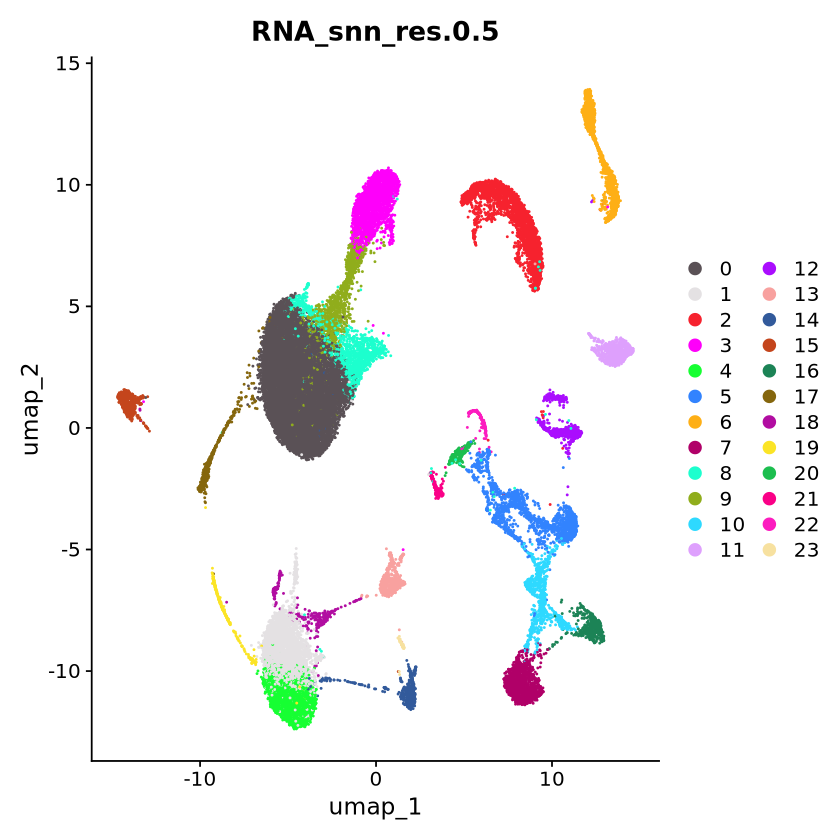

In [20]:
DimPlot(ref, reduction = "umap", cols = "polychrome", group.by = "RNA_snn_res.0.5")

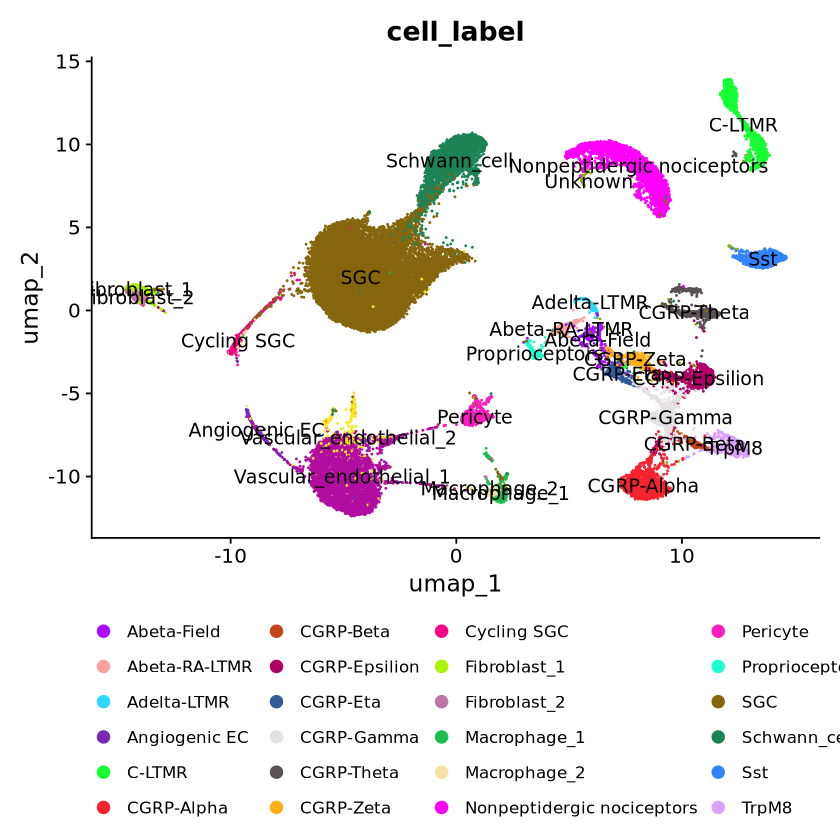

In [21]:
DimPlot(ref, reduction = "umap", 
              cols = colors_polychrome, 
        label=T,
              group.by = "cell_label") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

### Normalize, umap on Xenium 

In [22]:
DefaultAssay(xenium.obj) <- "Xenium"
xenium.obj <- NormalizeData(xenium.obj)
xenium.obj <- FindVariableFeatures(xenium.obj)

DefaultAssay(xenium.obj) <- "Xenium"

# process xenium 
xenium.obj <- FindVariableFeatures(xenium.obj) %>%
              ScaleData() %>%
              RunPCA(npcs = 20) %>%
              RunUMAP(dims = 1:16, return.model=TRUE) %>%
              FindNeighbors(reduction = "pca", dims = 1:16) %>%
              FindClusters(resolution = 0.6)


Normalizing layer: counts

Finding variable features for layer counts

Finding variable features for layer counts

PC_ 1 
Positive:  Scn9a, Slc17a6, Nefl, Asic2, Nefm, Bex1, Ret, Atp1b1, Scn11a, Calcb 
	   F2rl2, Syp, Arhgdig, Scn10a, Camk2a, Ntrk1, 6330403K07Rik, Nptx2, Calca, Nrsn1 
	   Resp18, Oprm1, Nefh, Nmb, Rph3a, Ache, P2rx3, Vamp1, Gabra2, Rprm 
Negative:  Prx, Ogn, Cldn19, Pllp, Ugt8a, Ncmap, Mlip, Bcas1, Mbp, Tgfbr2 
	   Col3a1, Sema3b, Cav1, Nr4a2, Emid1, Art3, Tagln, Igfbp7, Gjc3, P2rx7 
	   Smoc2, Fxyd3, Sgk1, Pou3f1, Sox10, Sema5a, Hbb-bt, Il34, Anxa1, Ldlrad3 
PC_ 2 
Positive:  Abcb1a, Ly6a, Pecam1, Esam, Ly6c1, Igfbp7, Cldn5, Slco1a4, Cxcl12, Nrp1 
	   Vwf, Anxa1, S1pr1, Mef2c, Grrp1, C1qa, Rgs5, H2-Ab1, Hbb-bt, Csf1r 
	   Entpd1, Ctla2a, Tyrobp, Mrc1, Myh11, Tgfb1, Efnb2, Cx3cr1, Adgre1, Tnfrsf1a 
Negative:  Plp1, Sox10, Art3, Erbb3, Gjc3, Mbp, Ugt8a, Itgb8, Sema3b, Cldn19 
	   Ldhb, Prx, Ncmap, Pllp, Dhh, Mlip, Bcas1, Aspa, Adamts5, Cdkn1a 
	   Sfrp5, Nr4a2, Vat1l, F

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 72457
Number of edges: 2322045

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9113
Number of communities: 21
Elapsed time: 24 seconds


In [23]:
colnames(xenium.obj@meta.data)

[1] "orig.ident"                  "nCount_RNA"                 
 [3] "nFeature_RNA"                "nCount_Xenium"              
 [5] "nFeature_Xenium"             "cell_id"                    
 [7] "x_centroid"                  "y_centroid"                 
 [9] "transcript_counts"           "control_probe_counts"       
[11] "genomic_control_counts"      "control_codeword_counts"    
[13] "unassigned_codeword_counts"  "deprecated_codeword_counts" 
[15] "total_counts"                "cell_area"                  
[17] "nucleus_area"                "nucleus_count"              
[19] "segmentation_method"         "sample_id"                  
[21] "output_id"                   "region_id"                  
[23] "slide_id"                    "n_genes_by_counts"          
[25] "log1p_n_genes_by_counts"     "log1p_total_counts"         
[27] "pct_counts_in_top_10_genes"  "pct_counts_in_top_20_genes" 
[29] "pct_counts_in_top_50_genes"  "pct_counts_in_top_150_genes"
[31] "batch"                       "X_scvi_batch"               
[33] "X_scvi_labels"               "gene_name"                  
[35] "nCount_Xenium_log"           "nFeature_Xenium_log"        
[37] "Xenium_snn_res.0.6"          "seurat_clusters"

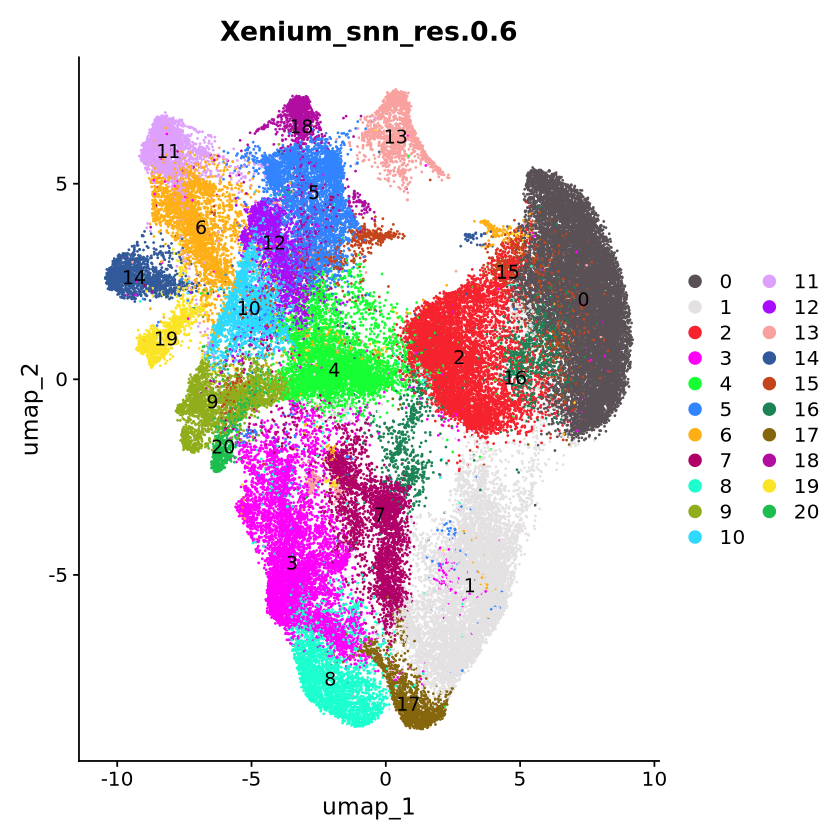

In [24]:
# Plot UMAP
DimPlot(xenium.obj, group.by = "Xenium_snn_res.0.6", 
        cols = "polychrome", label=TRUE, label.size = 4)

# markers <- c('leiden_scVI_1')
# FeaturePlot(xenium.obj, features = markers)

## Run FindAnchors for Label Transfer

[1] 474
[1] "subset ref to common genes and process ref"


Normalizing layer: counts

Finding variable features for layer counts

Centering and scaling data matrix

Warning message:
“The following 5 features requested have zero variance; running reduction without them: Jak1, Arhgdig, Il2rb, Lag3, Il13ra1”
PC_ 1 
Positive:  Snhg11, Calcb, Scn9a, Ret, Scn10a, Slc17a6, Scn11a, Asic2, Cd44, Nrsn1 
	   Nmb, F2rl2, Pkib, Tac1, Nptx2, Syp, Rasgrp1, Camk2a, Piezo2, Iqsec2 
	   6330403K07Rik, Ngfr, Bdnf, Gap43, Il6st, Ctxn3, Frmd3, Sox11, Rph3a, Ahi1 
Negative:  Plp1, Fabp7, Ptprz1, Ednrb, Ldhb, Itgb8, Crip1, Sfrp5, Rarres2, Aspa 
	   Art3, Adamts5, Rbp1, Mgst1, Fmo1, Bcan, Sox10, Sema3b, Cald1, Igfbp7 
	   Fxyd3, Gja1, Ogn, Dhh, Gjc3, S100a16, Cxcl12, Foxd3, Entpd1, Erbb3 
PC_ 2 
Positive:  Plp1, Fabp7, Ptprz1, Ednrb, Ldhb, Itgb8, Sfrp5, Aspa, Bcan, Ntrk2 
	   Mbp, Rarres2, Sox10, Tafa5, Fmo1, Sema3b, Art3, Dhh, Kit, Pcdh10 
	   Erbb3, Kcnj10, S1pr3, Gjc3, Fxyd3, Foxd3, Crabp1, Ogn, Slc1a3, Ugt8a 
Negative:  Ly6c1, Cxcl12, Igfbp7, Ly6a, Cldn5, Ctla2a,

[1] "Find Anchors"


Projecting cell embeddings

Finding neighborhoods

Finding anchors

	Found 15759 anchors



[1] "label transfer"


Finding integration vectors

Warning message:
“The `slot` argument of `GetAssayData()` is deprecated as of SeuratObject 5.0.0.
ℹ Please use the `layer` argument instead.
ℹ The deprecated feature was likely used in the Seurat package.
  Please report the issue at <https://github.com/satijalab/seurat/issues>.”
Finding integration vector weights

Predicting cell labels



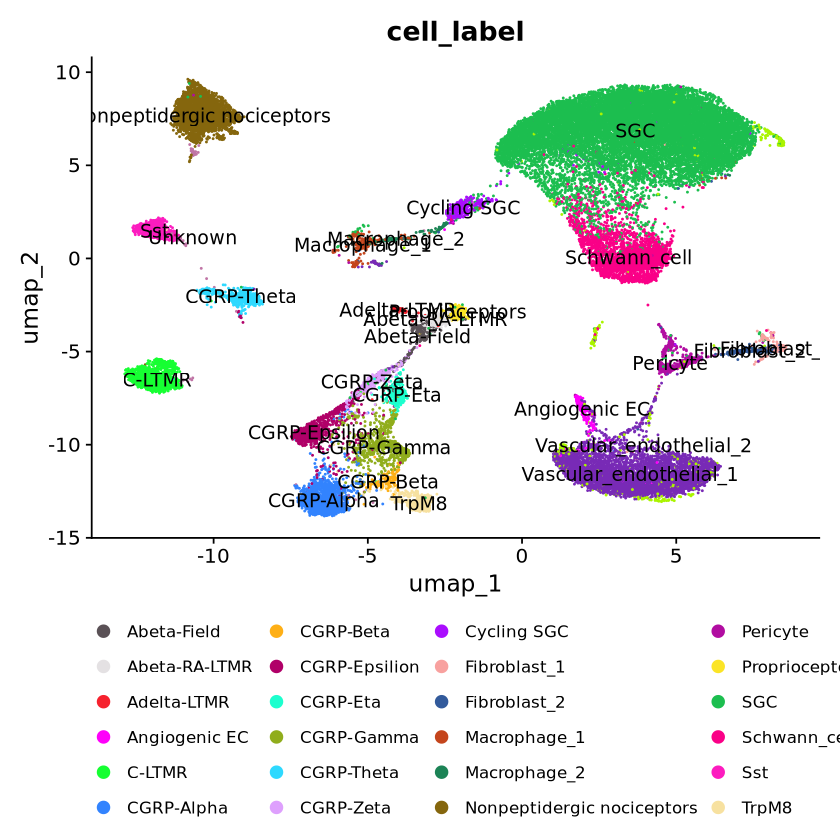

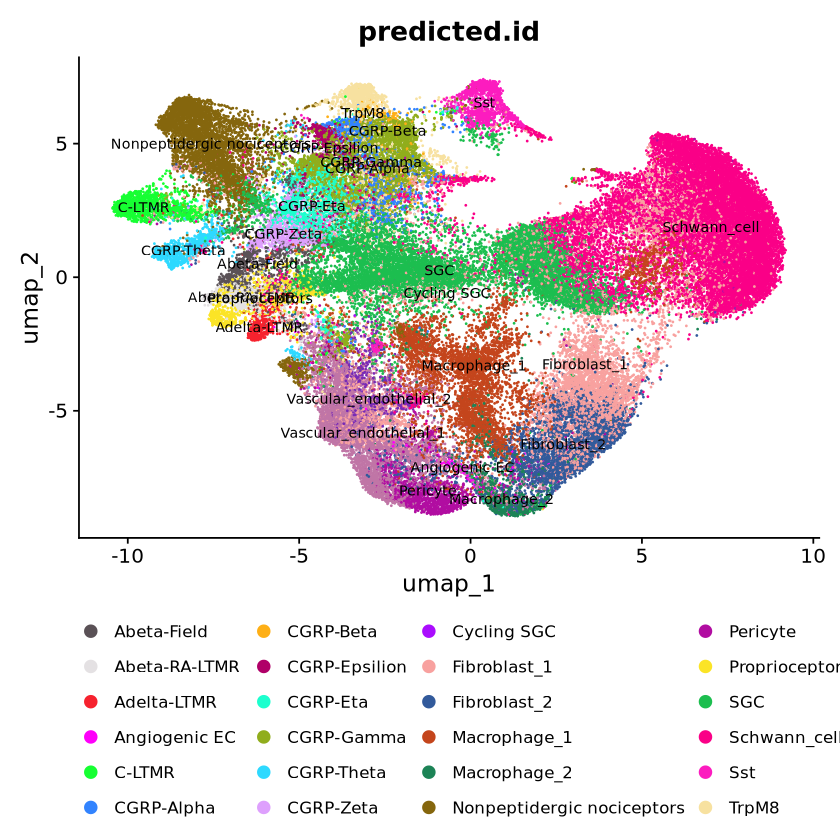

In [25]:
# Run on gene intersection
common_genes <- intersect(rownames(xenium.obj), rownames(ref))
print(length(common_genes))

print('subset ref to common genes and process ref')
ref_subset <- CreateSeuratObject(counts = ref[["RNA"]]$counts[common_genes,],
                                 meta = ref@meta.data) %>%
                                NormalizeData() %>%
                                FindVariableFeatures() %>%
                                ScaleData() %>%
                                RunPCA() %>%
                                RunUMAP(dims=1:15) 

# Visualize
DimPlot(ref_subset, reduction = "umap", 
              # cols = colors_polychrome, 
        cols = "polychrome", 
        label=T,
              group.by = "cell_label") +
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

# Find anchors
print('Find Anchors')
ref[["RNA"]]$counts <- as(object = ref[["RNA"]]$counts, Class = "dgCMatrix")

xenium.obj[["Xenium"]]$counts <- as(object = xenium.obj[["Xenium"]]$counts, Class = "dgCMatrix")

anchors_from_ref <- FindTransferAnchors(reference = ref_subset,
                                         query = xenium.obj,
                                         query.assay = "Xenium",
                                         features = common_genes,
                                         dims = 1:20,
                                         reference.reduction = "pca")

# Label transfer
print('label transfer')
label_transfer <- TransferData(anchorset = anchors_from_ref,
                               refdata = ref_subset$cell_label,
                               dims = 1:20)

# add predicted id
xenium.obj <- AddMetaData(object = xenium.obj, metadata = label_transfer, col.name = 'predicted.id')

# visualize
DimPlot(xenium.obj, group.by = c("predicted.id"), 
        cols = "polychrome", 
        label=T, label.size = 3)+
  theme(
    legend.position = "bottom",       
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

# save
# Export RDS
saveRDS(xenium.obj, file.path(output_dir, 'xenium_processed_labeltransfer.rds'))

# label transfer
write.csv(label_transfer, file = file.path(output_dir, "label_transfer_xenium.csv"), row.names = TRUE)

In [26]:
ref

An object of class Seurat 
28737 features across 36241 samples within 1 assay 
Active assay: RNA (28737 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 3 dimensional reductions calculated: latent, umap, pca

## Xenium and Sequencing Co-Embedding

In [27]:
# Standard PCA/UMAP
standard_dim_reduction <- function(obj, seed = 1234){

    DefaultAssay(obj) <- "RNA"
    set.seed(seed)

    obj <- NormalizeData(obj)
    obj <- FindVariableFeatures(obj)
    obj <- ScaleData(obj)
    obj <- RunPCA(obj)

    obj <- FindNeighbors(obj, dims = 1:10, reduction = "pca")
    obj <- FindClusters(obj, resolution = 1, cluster.name = "unintegrated_clusters")

    obj <- RunUMAP(obj, dims = 1:10, reduction = "pca",
                   reduction.name = "umap.unintegrated")

    return(obj)
}

In [28]:
# CCA integration
integrate_objects <- function(comb_obj,
                              integration_method = CCAIntegration,
                              reduction_name = "integrated.cca",
                              seed = 1234){

    set.seed(seed)

    comb_obj <- IntegrateLayers(
        object = comb_obj,
        method = integration_method,
        orig.reduction = "pca",
        new.reduction = reduction_name,
        verbose = FALSE
    )

    # After integration, rejoin layers
    comb_obj[["RNA"]] <- JoinLayers(comb_obj[["RNA"]])

    comb_obj <- FindNeighbors(comb_obj, reduction = reduction_name, dims = 1:20)
    comb_obj <- FindClusters(comb_obj, resolution = 1)

    comb_obj <- RunUMAP(comb_obj, dims = 1:20,
                        reduction = reduction_name,
                        seed.use = seed)

    return(comb_obj)
}

In [29]:
# Prepare Xenium + Reference
xenium_full <- xenium.obj
DefaultAssay(xenium_full) <- "Xenium"

xenium_full_layer <- DietSeurat(
    object = xenium_full,
    assays = "Xenium",
    layers = "counts"
)
xenium_full_layer <- RenameAssays(xenium_full_layer, Xenium = "RNA")

ref_layer <- DietSeurat(
    object = ref_subset,
    assays = "RNA",
    layers = "counts"
)

# Tag modality
ref_layer$modality <- "ref"
xenium_full_layer$modality <- "xen"

# Merge full datasets
comb <- merge(ref_layer, y = xenium_full_layer)
cat("Full combined dataset:", paste(dim(comb), collapse = " x "), "\n")

Renaming default assay from Xenium to RNA

Warning message:
“Key ‘xenium_’ taken, using ‘rna_’ instead”


Full combined dataset: 475 x 108698 


In [30]:
# Run PCA / CCA / UMAP

comb <- standard_dim_reduction(comb)
comb_cca <- integrate_objects(comb, reduction_name = "integrated.cca", seed = 1)

# Save RDS
saveRDS(comb_cca, file.path(output_dir, "xenium_ref_comb_full.rds"))

Normalizing layer: counts.SeuratProject

Normalizing layer: counts.adata_xenium

Finding variable features for layer counts.SeuratProject

Finding variable features for layer counts.adata_xenium

Centering and scaling data matrix

PC_ 1 
Positive:  Scn9a, Slc17a6, Asic2, Ret, Scn11a, Calcb, F2rl2, Syp, Scn10a, Bex1 
	   Camk2a, Arhgdig, Nptx2, 6330403K07Rik, Atp1b1, Nmb, Nrsn1, Ntrk1, Cd44, Snhg11 
	   Rph3a, Tac1, Ngfr, P2rx3, Oprm1, Resp18, Calca, Ache, Nefl, Trpv2 
Negative:  Prx, Ogn, Cldn19, Pllp, Ncmap, Ugt8a, Bcas1, Mlip, Tgfbr2, Igfbp7 
	   Emid1, Sema3b, Fxyd3, Crip1, Mbp, Cav1, Col3a1, Tagln, Pou3f1, Plp1 
	   Sgk1, Art3, Nr4a2, Gjc3, Rbp1, P2rx7, Ctla2a, Rarres2, Nes, Anxa1 
PC_ 2 
Positive:  Ly6a, Ly6c1, Pecam1, Esam, Abcb1a, Cldn5, Cxcl12, Slco1a4, Igfbp7, Ctla2a 
	   Mef2c, Nrp1, Grrp1, Vwf, S1pr1, Entpd1, Anxa1, H2-D1, Tgfb2, Rgs5 
	   Hbb-bt, Cd38, C1qa, Csf1r, Myh11, Tcf7, Tgfb1, Tyrobp, Efnb2, Tnfrsf1a 
Negative:  Plp1, Sox10, Art3, Mbp, Gjc3, Erbb3, Itgb8, Ugt8a, Sem

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 108698
Number of edges: 3265367

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.9065
Number of communities: 37
Elapsed time: 53 seconds


16:19:17 UMAP embedding parameters a = 0.9922 b = 1.112

16:19:17 Read 108698 rows and found 10 numeric columns

16:19:17 Using Annoy for neighbor search, n_neighbors = 30

16:19:17 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:19:30 Writing NN index file to temp file /tmp/RtmpIkXuqW/file178e50aac7c0

16:19:30 Searching Annoy index using 1 thread, search_k = 3000

16:20:22 Annoy recall = 100%

16:20:22 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:20:27 Initializing from normalized Laplacian + noise (using RSpectra)

16:20:38 Commencing optimization for 200 epochs, with 4617782 positive edges

16:20:38 Using rng type: pcg

16:21:49 Optimization finished

Warning message:
“The `slot` argument of `SetAssayData()` is depr

Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 108698
Number of edges: 3752767

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8990
Number of communities: 31
Elapsed time: 46 seconds


16:27:38 UMAP embedding parameters a = 0.9922 b = 1.112

16:27:38 Read 108698 rows and found 20 numeric columns

16:27:38 Using Annoy for neighbor search, n_neighbors = 30

16:27:38 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

16:27:52 Writing NN index file to temp file /tmp/RtmpIkXuqW/file178e2b9d69e2

16:27:52 Searching Annoy index using 1 thread, search_k = 3000

16:28:44 Annoy recall = 100%

16:28:45 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

16:28:49 Initializing from normalized Laplacian + noise (using RSpectra)

16:28:56 Commencing optimization for 200 epochs, with 5071466 positive edges

16:28:56 Using rng type: pcg

16:30:10 Optimization finished



Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`

Rasterizing points since number of points exceeds 100,000.
To disable this behavior set `raster=FALSE`



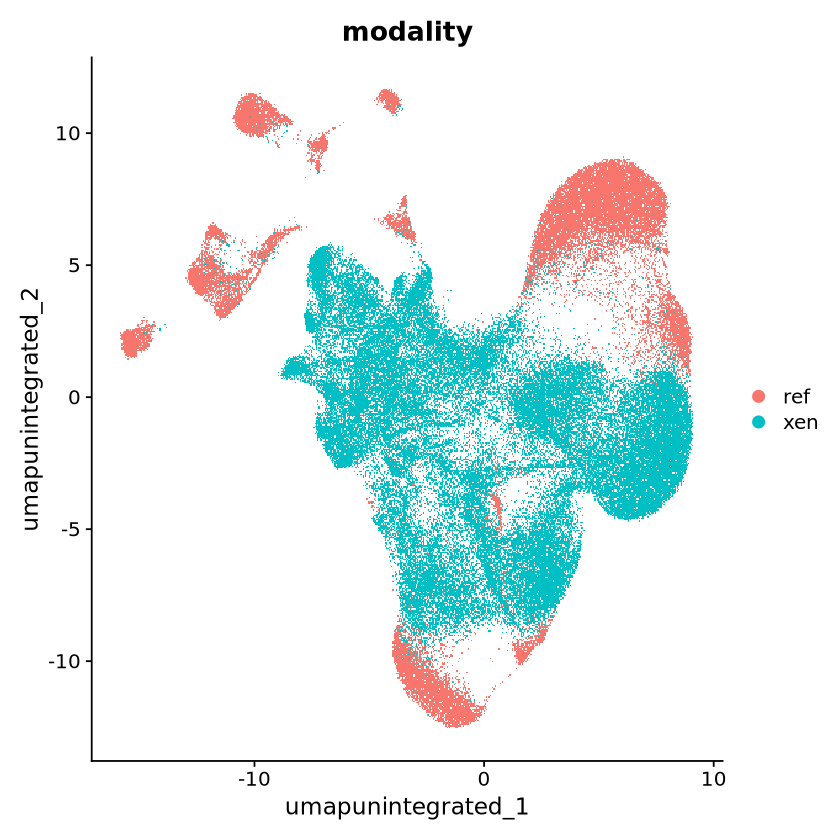

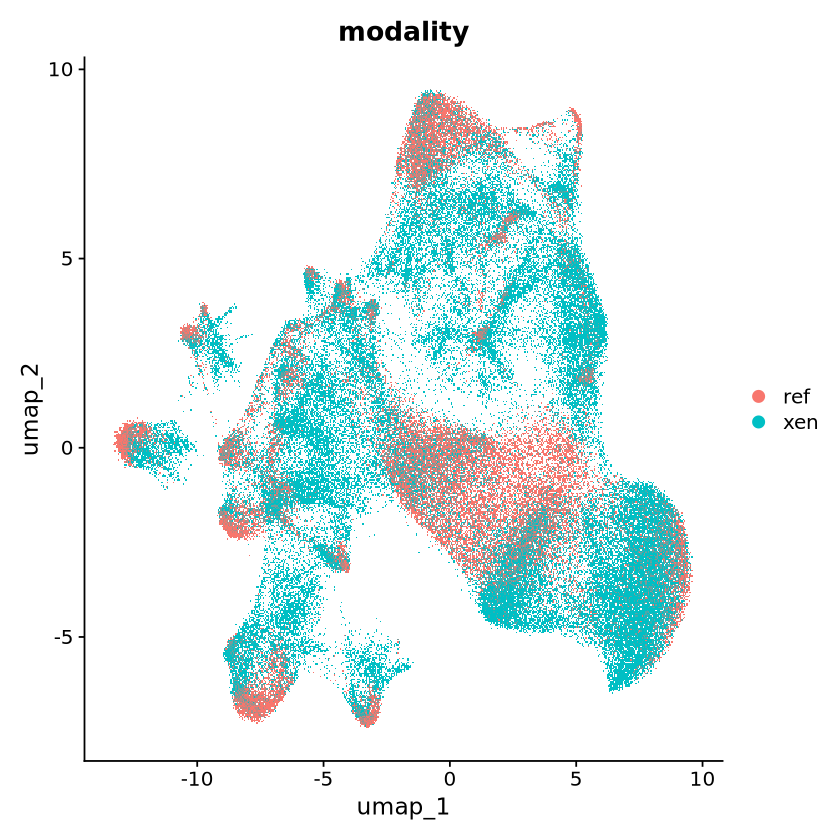

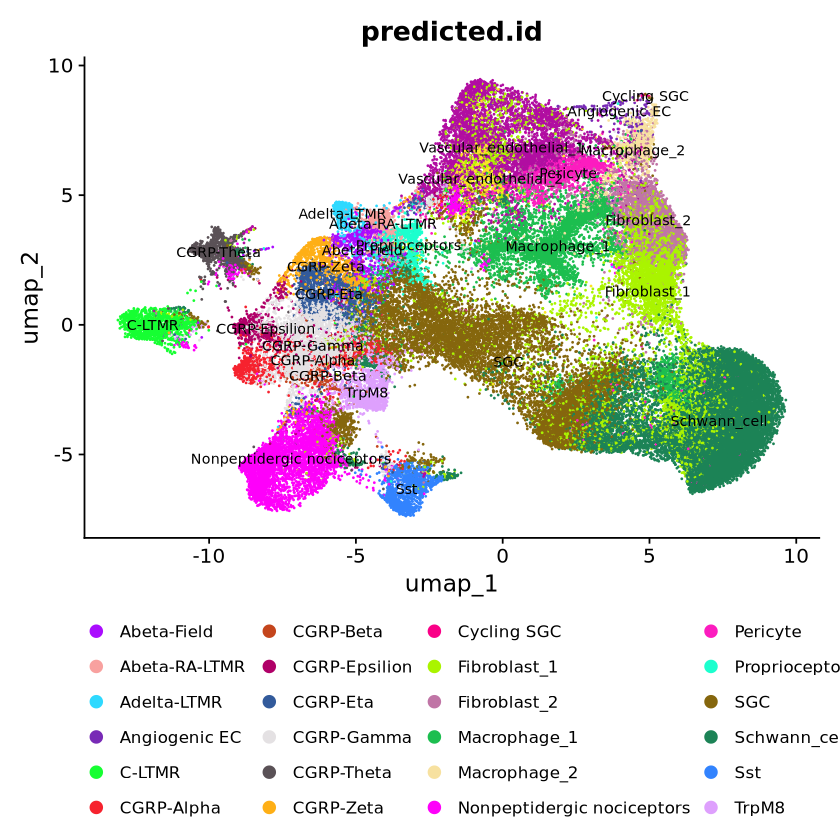

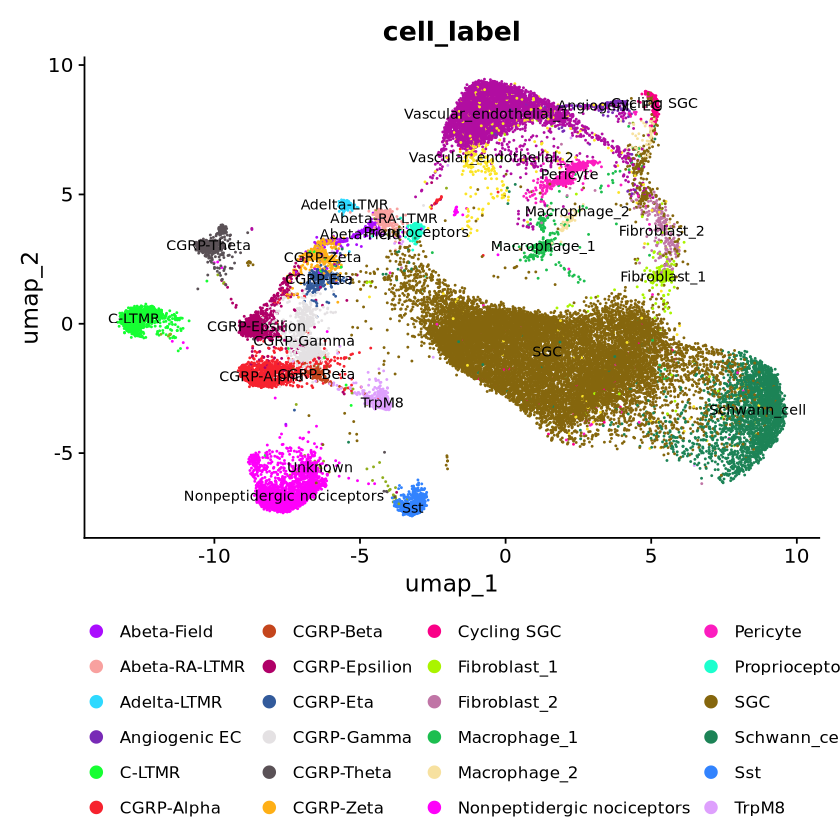

In [31]:
DimPlot(comb, reduction = "umap.unintegrated", group.by = "modality")
DimPlot(comb_cca, reduction = "umap", group.by = "modality")

DimPlot(
    subset(comb_cca, modality == "xen"),
    reduction = "umap",
    group.by = "predicted.id",
    label = TRUE,
    label.size = 3,
    cols = colors_polychrome
) +
  theme(
    legend.position = "bottom",
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )

DimPlot(
    subset(comb_cca, modality == "ref"),
    reduction = "umap",
    group.by = "cell_label",
    label = TRUE,
    label.size = 3,
    cols = colors_polychrome
) +
  theme(
    legend.position = "bottom",
    legend.text = element_text(size = 10),
    legend.key.size = unit(0.5, "cm")
  )